In [ ]:
# mounting google drive so we can read the csv files directly from there
from google.colab import drive
drive.mount('/content/drive')

# importing libraries
import pandas as pd
import numpy as np

# setting the folder path where all 7 csv files are uploaded in drive
path = '/content/drive/MyDrive/OULAD/'




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Pre-processing the 7 csv files seperately

In [ ]:
# ================================
# 1. STUDENT INFO
# ================================
# loading the file
studentInfo = pd.read_csv(path + 'studentInfo.csv')
# checking how the raw data looks
print("Before Cleaning - studentInfo")
studentInfo.head()


Before Cleaning - studentInfo


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [ ]:
# checking missing values
studentInfo.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
gender,0
region,0
highest_education,0
imd_band,0
age_band,0
num_of_prev_attempts,0
studied_credits,0


In [ ]:
# checking data types just to be safe before merging later
studentInfo.dtypes

,0
code_module,object
code_presentation,object
id_student,int64
gender,object
region,object
highest_education,object
imd_band,object
age_band,object
num_of_prev_attempts,int64
studied_credits,int64


In [ ]:
# dropping column we don't need
studentInfo.drop(columns=['num_of_prev_attempts'], inplace=True, errors='ignore')
# dropping duplicate rows if any
studentInfo.drop_duplicates(inplace=True)
# imd_band has missing values, filling with "Unknown" instead of dropping rows
studentInfo['imd_band'] = studentInfo['imd_band'].fillna('Unknown')
# dropping rows where final_result is missing (very few, if any)
studentInfo.dropna(subset=['final_result'], inplace=True)
# checking the data again after cleaning
print("After Cleaning - studentInfo")
studentInfo.head()

After Cleaning - studentInfo


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,60,N,Pass


In [ ]:
# ================================
# 2. STUDENT REGISTRATION
# ================================
studentRegistration = pd.read_csv(path + 'studentRegistration.csv')
print("Before Cleaning - studentRegistration")
studentRegistration.head()


Before Cleaning - studentRegistration


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159,?
1,AAA,2013J,28400,-53,?
2,AAA,2013J,30268,-92,12
3,AAA,2013J,31604,-52,?
4,AAA,2013J,32885,-176,?


In [ ]:
studentRegistration.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
date_registration,0
date_unregistration,0


In [ ]:
studentRegistration.dtypes

,0
code_module,object
code_presentation,object
id_student,int64
date_registration,object
date_unregistration,object


In [ ]:
# dropping duplicate rows if any
studentRegistration.drop_duplicates(inplace=True)
# date_registration also has a few missing values, filling with 0 (treating as registered on start day)
studentRegistration['date_registration'] = studentRegistration['date_registration'].fillna(0)
# date_unregistration is stored as text, converting to numbers so we can compare it properly
studentRegistration['date_unregistration'] = pd.to_numeric(studentRegistration['date_unregistration'], errors='coerce')
# date_unregistration is empty when student never withdrew
# making a new column: 1 = withdrew, 0 = did not withdraw
studentRegistration['withdrawn'] = studentRegistration['date_unregistration'].notna().astype(int)
# removing rows where the unregistration date doesn't make sense (before course started)
studentRegistration = studentRegistration[
    ~((studentRegistration['withdrawn'] == 1) & (studentRegistration['date_unregistration'] < 0))
]
print("After Cleaning - studentRegistration")
studentRegistration.head()

After Cleaning - studentRegistration


,code_module,code_presentation,id_student,date_registration,date_unregistration,withdrawn
0,AAA,2013J,11391,-159,NaN,0
1,AAA,2013J,28400,-53,NaN,0
2,AAA,2013J,30268,-92,12.0,1
3,AAA,2013J,31604,-52,NaN,0
4,AAA,2013J,32885,-176,NaN,0


In [ ]:
studentRegistration.isnull().sum()

,0
code_module,0
code_presentation,0
id_student,0
date_registration,0
date_unregistration,22521
withdrawn,0


In [ ]:
# ================================
# 3. ASSESSMENTS
# ================================
assessments = pd.read_csv(path + 'assessments.csv')
print("Before Cleaning - assessments")
assessments.head()


Before Cleaning - assessments


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


In [ ]:
assessments.isnull().sum()

,0
code_module,0
code_presentation,0
id_assessment,0
assessment_type,0
date,0
weight,0


In [ ]:
assessments.dtypes


,0
code_module,object
code_presentation,object
id_assessment,int64
assessment_type,object
date,object
weight,float64


In [ ]:
# dropping duplicate rows if any
assessments.drop_duplicates(inplace=True)
# some rows have missing deadline date (mostly Exam rows), removing them
assessments['date'] = pd.to_numeric(assessments['date'], errors='coerce')
assessments = assessments[assessments['date'].notna()]
# converting date column to integer since deadlines are day counts not decimals
assessments['date'] = assessments['date'].astype(int)

print("After Cleaning - assessments")
assessments.head()

After Cleaning - assessments


,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19,10.0
1,AAA,2013J,1753,TMA,54,20.0
2,AAA,2013J,1754,TMA,117,20.0
3,AAA,2013J,1755,TMA,166,20.0
4,AAA,2013J,1756,TMA,215,30.0


In [ ]:
# ================================
# 4. STUDENT ASSESSMENT
# ================================
studentAssessment = pd.read_csv(path + 'studentAssessment.csv')
print("Before Cleaning - studentAssessment")
studentAssessment.head()


Before Cleaning - studentAssessment


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78
1,1752,28400,22,0,70
2,1752,31604,17,0,72
3,1752,32885,26,0,69
4,1752,38053,19,0,79


In [ ]:
studentAssessment.isnull().sum()


,0
id_assessment,0
id_student,0
date_submitted,0
is_banked,0
score,0


In [ ]:
studentAssessment.dtypes

,0
id_assessment,int64
id_student,int64
date_submitted,int64
is_banked,int64
score,object


In [ ]:
# dropping duplicate rows if any
studentAssessment.drop_duplicates(inplace=True)
# is_banked = 1 means the score is old/reused, not a real submission this time
# removing those rows since we only want actual submission behavior
studentAssessment = studentAssessment[studentAssessment['is_banked'] == 0]
studentAssessment.drop(columns=['is_banked'], inplace=True)
# dropping rows with missing submission date or score
studentAssessment.dropna(subset=['date_submitted', 'score'], inplace=True)
print("After Cleaning - studentAssessment")
studentAssessment.head()

After Cleaning - studentAssessment


,id_assessment,id_student,date_submitted,score
0,1752,11391,18,78
1,1752,28400,22,70
2,1752,31604,17,72
3,1752,32885,26,69
4,1752,38053,19,79


In [ ]:
# ================================
# 5. STUDENT VLE (biggest file, needs aggregation)
# ================================
studentVle = pd.read_csv(path + 'studentVle.csv')
print("Before Cleaning - studentVle")
studentVle.head()


Before Cleaning - studentVle


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1


In [ ]:
studentVle.isnull().sum()


,0
code_module,0
code_presentation,0
id_student,0
id_site,0
date,0
sum_click,0


In [ ]:
# this file has repeated rows for same student+material+day with different click counts
# grouping them and adding up the clicks into one row
studentVle_clean = studentVle.groupby(
    ['code_module', 'code_presentation', 'id_student', 'id_site', 'date'],
    as_index=False
)['sum_click'].sum()
print("After Cleaning - studentVle")
studentVle_clean.head()

After Cleaning - studentVle


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,11391,546614,-5,7
1,AAA,2013J,11391,546614,0,10
2,AAA,2013J,11391,546614,1,9
3,AAA,2013J,11391,546614,2,3
4,AAA,2013J,11391,546614,6,1


In [ ]:
# ================================
# 6. VLE (material metadata)
# ================================
vle = pd.read_csv(path + 'vle.csv')
print("Before Cleaning - vle")
vle.head()


Before Cleaning - vle


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,?,?
1,546712,AAA,2013J,oucontent,?,?
2,546998,AAA,2013J,resource,?,?
3,546888,AAA,2013J,url,?,?
4,547035,AAA,2013J,resource,?,?


In [ ]:
vle.isnull().sum()

,0
id_site,0
code_module,0
code_presentation,0
activity_type,0
week_from,0
week_to,0


In [ ]:
# week_from and week_to have a lot of missing values (shown as ?)
# these mean the material doesn't belong to a specific week, filling with -1 instead of dropping
vle['week_from'] = pd.to_numeric(vle['week_from'], errors='coerce').fillna(-1)
vle['week_to'] = pd.to_numeric(vle['week_to'], errors='coerce').fillna(-1)
print("After Cleaning - vle")
vle.head()

After Cleaning - vle


,id_site,code_module,code_presentation,activity_type,week_from,week_to
0,546943,AAA,2013J,resource,-1.0,-1.0
1,546712,AAA,2013J,oucontent,-1.0,-1.0
2,546998,AAA,2013J,resource,-1.0,-1.0
3,546888,AAA,2013J,url,-1.0,-1.0
4,547035,AAA,2013J,resource,-1.0,-1.0


In [ ]:
# ================================
# 7. COURSES
# ================================
courses = pd.read_csv(path + 'courses.csv')
print("Before Cleaning - courses")
courses.head()

Before Cleaning - courses


,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240


In [ ]:
courses.isnull().sum()

,0
code_module,0
code_presentation,0
module_presentation_length,0


In [ ]:
# ================================
# SAVING ALL CLEANED FILES BACK TO DRIVE
# ================================
studentInfo.to_csv(path + 'studentInfo_clean.csv', index=False)
studentRegistration.to_csv(path + 'studentRegistration_clean.csv', index=False)
assessments.to_csv(path + 'assessments_clean.csv', index=False)
studentAssessment.to_csv(path + 'studentAssessment_clean.csv', index=False)
studentVle_clean.to_csv(path + 'studentVle_clean.csv', index=False)
vle.to_csv(path + 'vle_clean.csv', index=False)
courses.to_csv(path + 'courses_clean.csv', index=False)
print("All 7 files cleaned and saved!")

All 7 files cleaned and saved!


#Merging all the files into one dataframe

In [ ]:
# ================================
# STEP 1: SUBMISSION TIMING FEATURES
# ================================
# joining submission data with deadline data to know how early/late each submission was
sub = studentAssessment.merge(assessments, on='id_assessment')
# days_early = deadline - submission date (positive means submitted early, negative means late)
sub['days_early'] = sub['date'] - sub['date_submitted']

# now we get one row per student showing their average submission behavior
submission_features = sub.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    avg_days_early=('days_early', 'mean'),
    min_days_early=('days_early', 'min'),
    late_submission_count=('days_early', lambda x: (x < 0).sum()),
    total_submissions=('days_early', 'count')
).reset_index()

# ratio of assignments submitted late out of all assignments
submission_features['late_ratio'] = submission_features['late_submission_count'] / submission_features['total_submissions']


# ================================
# STEP 2: CLICK/ENGAGEMENT FEATURES
# ================================
# adding course length so we know how long each course runs
vle_merged = studentVle_clean.merge(courses, on=['code_module', 'code_presentation'])

# marking a click as "late" if it happened in the last 20% of the course duration
vle_merged['late_click'] = vle_merged['date'] > (0.8 * vle_merged['module_presentation_length'])

# aggregating click behavior per student per course
engagement_features = vle_merged.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique'),
    first_click_day=('date', 'min'),
    late_clicks=('late_click', 'sum')
).reset_index()

# ratio of clicks that happened right before the deadline period
engagement_features['late_click_ratio'] = engagement_features['late_clicks'] / engagement_features['total_clicks']


# ================================
# STEP 3: MERGE EVERYTHING TOGETHER
# ================================
final_df = studentInfo.merge(studentRegistration, on=['id_student', 'code_module', 'code_presentation'], how='left')
final_df = final_df.merge(submission_features, on=['id_student', 'code_module', 'code_presentation'], how='left')
final_df = final_df.merge(engagement_features, on=['id_student', 'code_module', 'code_presentation'], how='left')

# dropping students who withdrew, since their late/missing submissions aren't real procrastination
final_df = final_df[final_df['withdrawn'] == 0]

# some students might not have any vle or assessment activity after merging, dropping those rows
final_df.dropna(subset=['avg_days_early', 'late_click_ratio'], inplace=True)


# ================================
# STEP 4: CREATE THE RISK LABEL
# ================================
# using avg_days_early alone as the risk indicator
# testing showed combining two features with an AND rule pushed most students
# into Medium by default, since few students are extreme on both measures at once
# avg_days_early alone gives much better class balance and separability
early_33 = final_df['avg_days_early'].quantile(0.33)
early_66 = final_df['avg_days_early'].quantile(0.66)

print("avg_days_early 33rd percentile:", early_33)
print("avg_days_early 66th percentile:", early_66)

def label_risk(row):
    if row['avg_days_early'] >= early_66:
        return 'Low'
    elif row['avg_days_early'] <= early_33:
        return 'High'
    else:
        return 'Medium'

final_df['risk_label'] = final_df.apply(label_risk, axis=1)

# checking how many students fall into each risk category
print(final_df['risk_label'].value_counts())

# checking the real (unscaled) values behind the threshold rule, before scaling changes them
print("avg_days_early stats (before scaling):")
print(final_df['avg_days_early'].describe())


# ================================
# STEP 5: ENCODING CATEGORICAL COLUMNS
# ================================
# converting categorical columns into numbers so the model can use them
final_df = pd.get_dummies(final_df, columns=['gender', 'region', 'highest_education', 'age_band', 'disability', 'imd_band'])


# ================================
# STEP 6: SCALING NUMERIC FEATURES
# ================================
from sklearn.preprocessing import StandardScaler

num_cols = ['avg_days_early', 'min_days_early', 'late_ratio', 'total_clicks', 'active_days', 'first_click_day', 'late_click_ratio']
scaler = StandardScaler()
final_df[num_cols] = scaler.fit_transform(final_df[num_cols])


# ================================
# STEP 7: FINAL CHECK ON MERGED TABLE
# ================================
# dropping final_result so it doesn't leak into the model later (it's too closely tied to our target)
final_df.drop(columns=['final_result'], inplace=True)

# moving risk_label to the last column so it's easy to spot as the output/target
cols = [c for c in final_df.columns if c != 'risk_label'] + ['risk_label']
final_df = final_df[cols]

# saving the final merged and preprocessed table
final_df.to_csv(path + 'final_merged_data.csv', index=False)
print("Final merged dataset saved!")

avg_days_early 33rd percentile: -0.6
avg_days_early 66th percentile: 3.7142857142857144
risk_label
Low       7160
High      6994
Medium    6842
Name: count, dtype: int64
avg_days_early stats (before scaling):
count    20996.000000
mean        11.970599
std         23.905825
min        -71.000000
25%         -1.272727
50%          0.833333
75%         14.083333
max        236.000000
Name: avg_days_early, dtype: float64
Final merged dataset saved!


In [ ]:
# just confirming the merge didn't leave any unexpected nulls or duplicate rows
print("Final merged table shape:", final_df.shape)
print(final_df.head())


Final merged table shape: (20996, 54)
  code_module code_presentation  id_student  studied_credits  \
0         AAA             2013J       11391              240   
1         AAA             2013J       28400               60   
3         AAA             2013J       31604               60   
4         AAA             2013J       32885               60   
5         AAA             2013J       38053               60   

  date_registration  date_unregistration  withdrawn  avg_days_early  \
0              -159                  NaN        0.0       -0.425455   
1               -53                  NaN        0.0       -0.500752   
3               -52                  NaN        0.0       -0.417088   
4              -176                  NaN        0.0       -0.977634   
5              -110                  NaN        0.0       -0.584415   

   min_days_early  late_submission_count  ...  imd_band_20-30%  \
0        0.528469                    0.0  ...            False   
1        0.033543 

In [ ]:
print(final_df.isnull().sum())


code_module                                          0
code_presentation                                    0
id_student                                           0
studied_credits                                      0
date_registration                                    0
date_unregistration                              20996
withdrawn                                            0
avg_days_early                                       0
min_days_early                                       0
late_submission_count                                0
total_submissions                                    0
late_ratio                                           0
total_clicks                                         0
active_days                                          0
first_click_day                                      0
late_clicks                                          0
late_click_ratio                                     0
gender_F                                             0
gender_M  

In [ ]:
print(final_df.dtypes)

code_module                                       object
code_presentation                                 object
id_student                                         int64
studied_credits                                    int64
date_registration                                 object
date_unregistration                              float64
withdrawn                                        float64
avg_days_early                                   float64
min_days_early                                   float64
late_submission_count                            float64
total_submissions                                float64
late_ratio                                       float64
total_clicks                                     float64
active_days                                      float64
first_click_day                                  float64
late_clicks                                      float64
late_click_ratio                                 float64
gender_F                       

#EDA

In [ ]:
# ================================
# PART 3: EXPLORATORY DATA ANALYSIS
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setting a clean plotting style
sns.set_theme(style="whitegrid")

In [ ]:
# Load the final model-ready dataset
final_df = pd.read_csv(path + 'final_merged_data.csv')

print("Dataset loaded successfully!")
print("Shape:", final_df.shape)

Dataset loaded successfully!
Shape: (20996, 54)


In [ ]:
final_df.head()

,code_module,code_presentation,id_student,studied_credits,date_registration,date_unregistration,withdrawn,avg_days_early,min_days_early,late_submission_count,...,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_?,risk_label
0,AAA,2013J,11391,240,-159,NaN,0.0,-0.425455,0.528469,0.0,...,False,False,False,False,False,False,False,True,False,Medium
1,AAA,2013J,28400,60,-53,NaN,0.0,-0.500752,0.033543,2.0,...,True,False,False,False,False,False,False,False,False,Medium
2,AAA,2013J,31604,60,-52,NaN,0.0,-0.417088,0.528469,0.0,...,False,False,False,True,False,False,False,False,False,Medium
3,AAA,2013J,32885,60,-176,NaN,0.0,-0.977634,-1.649203,5.0,...,False,False,False,True,False,False,False,False,False,High
4,AAA,2013J,38053,60,-110,NaN,0.0,-0.584415,-0.560367,1.0,...,False,False,False,False,False,False,True,False,False,High


In [ ]:
print("Number of rows:", final_df.shape[0])
print("Number of columns:", final_df.shape[1])

print("\nColumn names:")
print(final_df.columns.tolist())

print("\nData types:")
print(final_df.dtypes)

Number of rows: 20996
Number of columns: 54

Column names:
['code_module', 'code_presentation', 'id_student', 'studied_credits', 'date_registration', 'date_unregistration', 'withdrawn', 'avg_days_early', 'min_days_early', 'late_submission_count', 'total_submissions', 'late_ratio', 'total_clicks', 'active_days', 'first_click_day', 'late_clicks', 'late_click_ratio', 'gender_F', 'gender_M', 'region_East Anglian Region', 'region_East Midlands Region', 'region_Ireland', 'region_London Region', 'region_North Region', 'region_North Western Region', 'region_Scotland', 'region_South East Region', 'region_South Region', 'region_South West Region', 'region_Wales', 'region_West Midlands Region', 'region_Yorkshire Region', 'highest_education_A Level or Equivalent', 'highest_education_HE Qualification', 'highest_education_Lower Than A Level', 'highest_education_No Formal quals', 'highest_education_Post Graduate Qualification', 'age_band_0-35', 'age_band_35-55', 'age_band_55<=', 'disability_N', 'disa

In [ ]:
print("\nMissing values:")
print(final_df.isnull().sum())


Missing values:
code_module                                          0
code_presentation                                    0
id_student                                           0
studied_credits                                      0
date_registration                                    0
date_unregistration                              20996
withdrawn                                            0
avg_days_early                                       0
min_days_early                                       0
late_submission_count                                0
total_submissions                                    0
late_ratio                                           0
total_clicks                                         0
active_days                                          0
first_click_day                                      0
late_clicks                                          0
late_click_ratio                                     0
gender_F                                        

In [ ]:
print("\nNumber of duplicate rows:", final_df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
numeric_cols = [
    'avg_days_early',
    'min_days_early',
    'late_ratio',
    'total_clicks',
    'active_days',
    'first_click_day',
    'late_click_ratio'
]

final_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
avg_days_early,20996.0,4.331752e-17,1.000024,-3.470810,-0.553992,-0.465892,0.088379,9.371554
min_days_early,20996.0,5.414690e-18,1.000024,-19.169563,-0.164427,0.132529,0.429484,23.789964
late_ratio,20996.0,2.165876e-17,1.000024,-0.932383,-0.932383,-0.390078,0.694531,2.321445
total_clicks,20996.0,1.082938e-17,1.000024,-0.922059,-0.654916,-0.332318,0.303813,11.948794
active_days,20996.0,-3.248814e-17,1.000024,-1.424056,-0.776200,-0.202384,0.593554,3.851346
first_click_day,20996.0,-5.414690e-17,1.000024,-1.355116,-0.692872,-0.113407,0.383276,19.257253
late_click_ratio,20996.0,4.331752e-17,1.000024,-0.994272,-0.695178,-0.215618,0.383093,27.869141


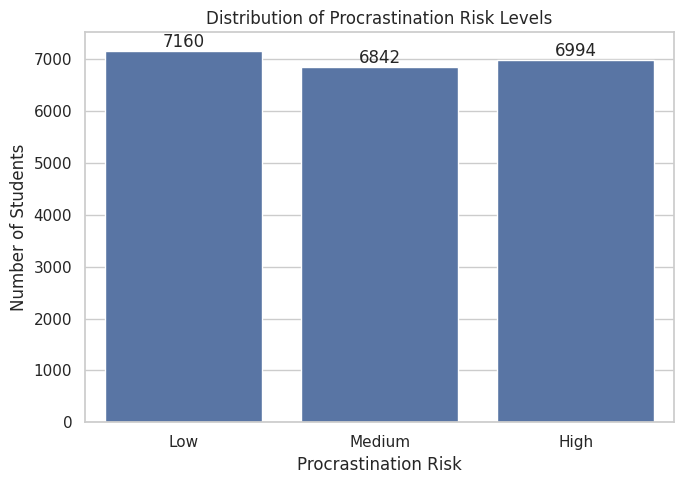

In [ ]:
#RISK CLASS DISTRIBUTION
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=final_df,
    x='risk_label',
    order=['Low', 'Medium', 'High']
)

plt.title('Distribution of Procrastination Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Number of Students')

# Add numbers above bars
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [ ]:
#PERCENTAGE
risk_counts = final_df['risk_label'].value_counts()
risk_percent = final_df['risk_label'].value_counts(normalize=True) * 100

risk_summary = pd.DataFrame({
    'Count': risk_counts,
    'Percentage': risk_percent.round(2)
})

risk_summary = risk_summary.reindex(['Low', 'Medium', 'High'])

print(risk_summary)

            Count  Percentage
risk_label                   
Low          7160       34.10
Medium       6842       32.59
High         6994       33.31


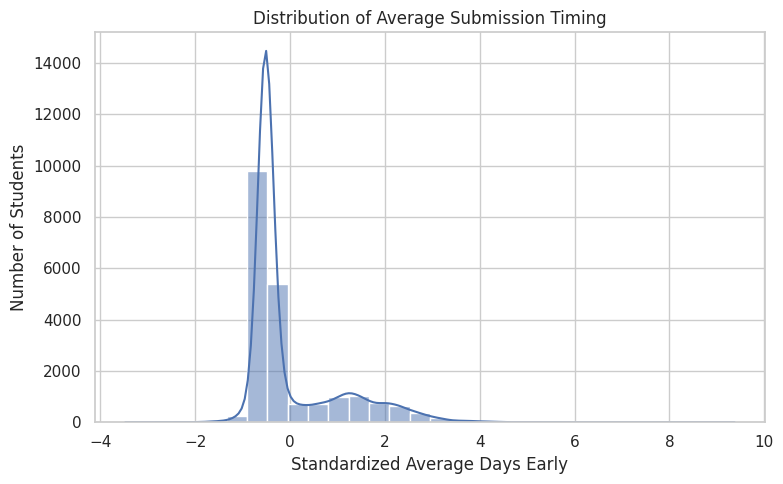

In [ ]:
#DISTRIBUTION OF SUBMISSION TIMING
plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='avg_days_early',
    bins=30,
    kde=True
)

plt.title('Distribution of Average Submission Timing')
plt.xlabel('Standardized Average Days Early')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

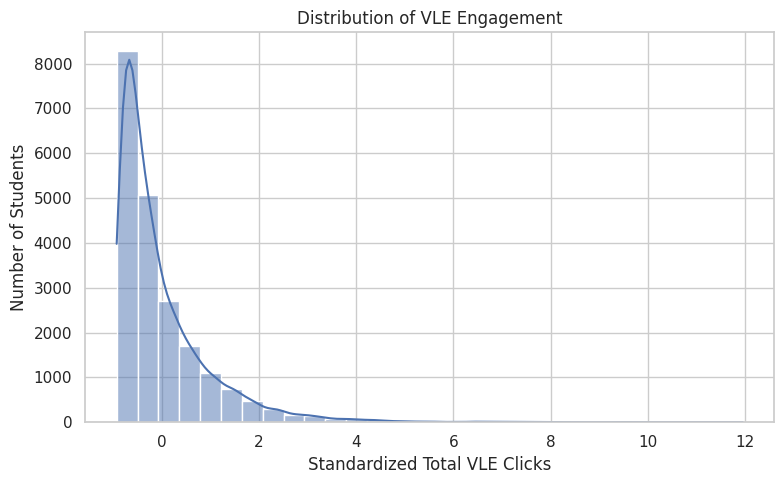

In [ ]:
#DISTRIBUTION OF VLE CLICKS
plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='total_clicks',
    bins=30,
    kde=True
)

plt.title('Distribution of VLE Engagement')
plt.xlabel('Standardized Total VLE Clicks')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

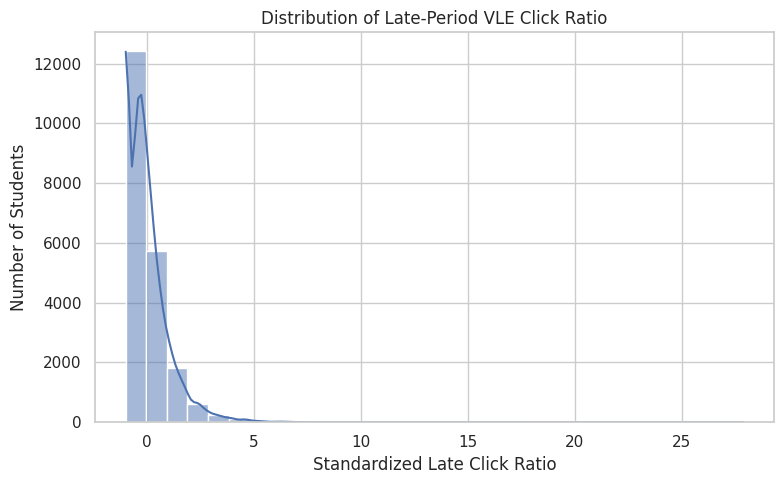

In [ ]:
#DISTRIBUTION OF LATE-CLICK RATIO
plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='late_click_ratio',
    bins=30,
    kde=True
)

plt.title('Distribution of Late-Period VLE Click Ratio')
plt.xlabel('Standardized Late Click Ratio')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

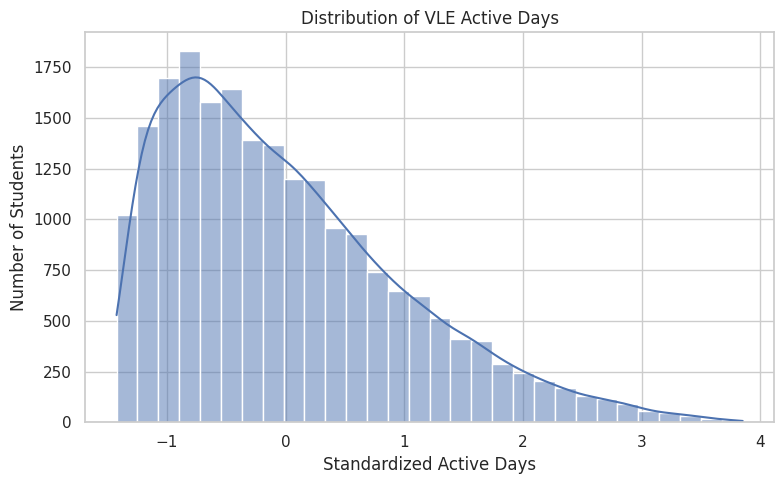

In [ ]:

# DISTRIBUTION OF ACTIVE DAYS
plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='active_days',
    bins=30,
    kde=True
)

plt.title('Distribution of VLE Active Days')
plt.xlabel('Standardized Active Days')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

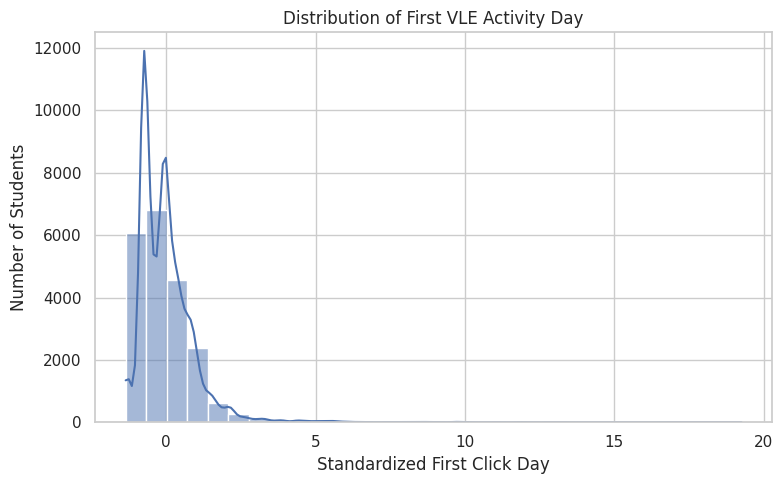

In [ ]:

# DISTRIBUTION OF FIRST CLICK DAY


plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='first_click_day',
    bins=30,
    kde=True
)

plt.title('Distribution of First VLE Activity Day')
plt.xlabel('Standardized First Click Day')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

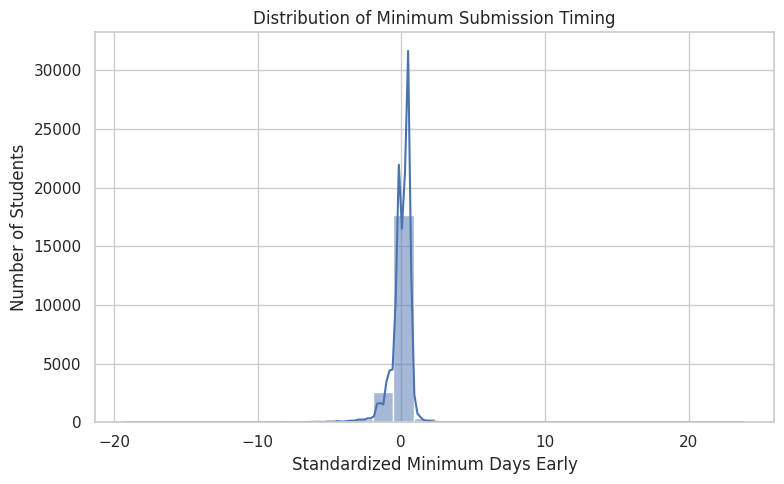

In [ ]:

# DISTRIBUTION OF MINIMUM DAYS EARLY


plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='min_days_early',
    bins=30,
    kde=True
)

plt.title('Distribution of Minimum Submission Timing')
plt.xlabel('Standardized Minimum Days Early')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

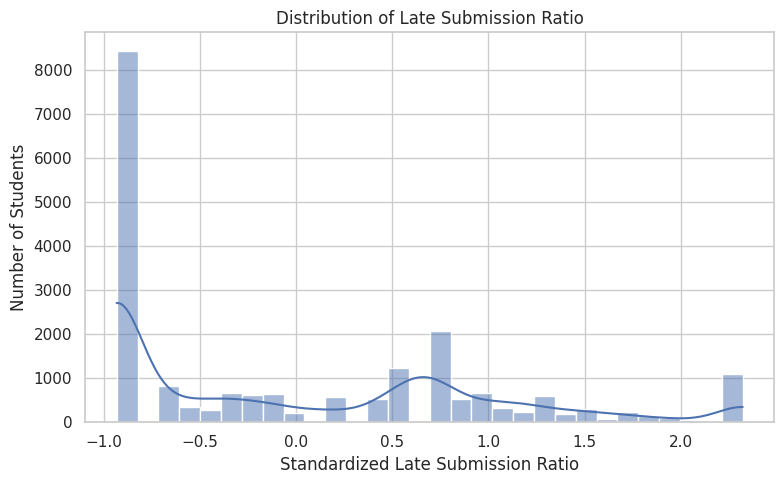

In [ ]:

# DISTRIBUTION OF LATE SUBMISSION RATIO


plt.figure(figsize=(8, 5))

sns.histplot(
    data=final_df,
    x='late_ratio',
    bins=30,
    kde=True
)

plt.title('Distribution of Late Submission Ratio')
plt.xlabel('Standardized Late Submission Ratio')
plt.ylabel('Number of Students')

plt.tight_layout()
plt.show()

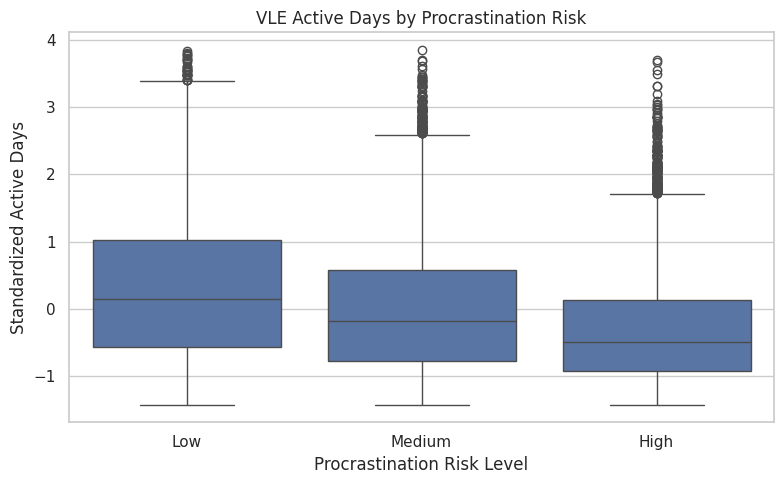

In [ ]:

# ACTIVE DAYS VS RISK


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='active_days',
    order=['Low', 'Medium', 'High']
)

plt.title('VLE Active Days by Procrastination Risk')
plt.xlabel('Procrastination Risk Level')
plt.ylabel('Standardized Active Days')

plt.tight_layout()
plt.show()

In [ ]:
print("Median active days by risk:")
display(
    final_df.groupby('risk_label')['active_days']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median active days by risk:


,active_days
risk_label,
Low,0.149310
Medium,-0.183874
High,-0.498547


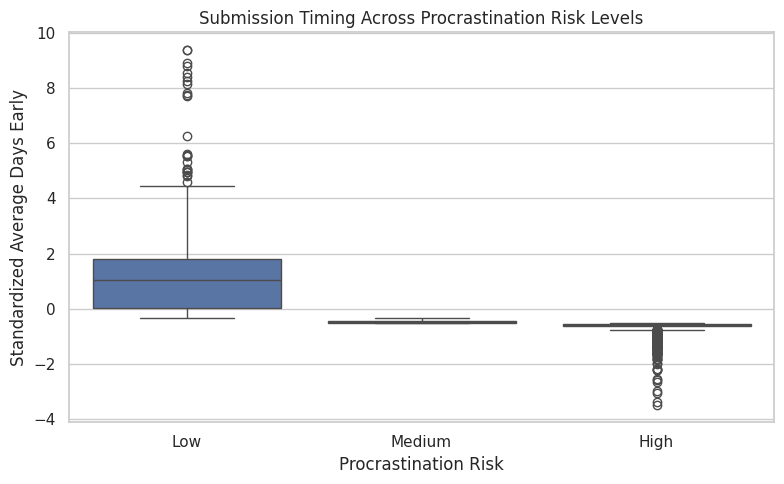

In [ ]:
#RISK VS SUBMISSION TIMING
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='avg_days_early',
    order=['Low', 'Medium', 'High']
)

plt.title('Submission Timing Across Procrastination Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Standardized Average Days Early')

plt.tight_layout()
plt.show()

In [ ]:
print("Median submission timing by risk:")
display(
    final_df.groupby('risk_label')['avg_days_early']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median submission timing by risk:


,avg_days_early
risk_label,
Low,1.042377
Medium,-0.467286
High,-0.584415


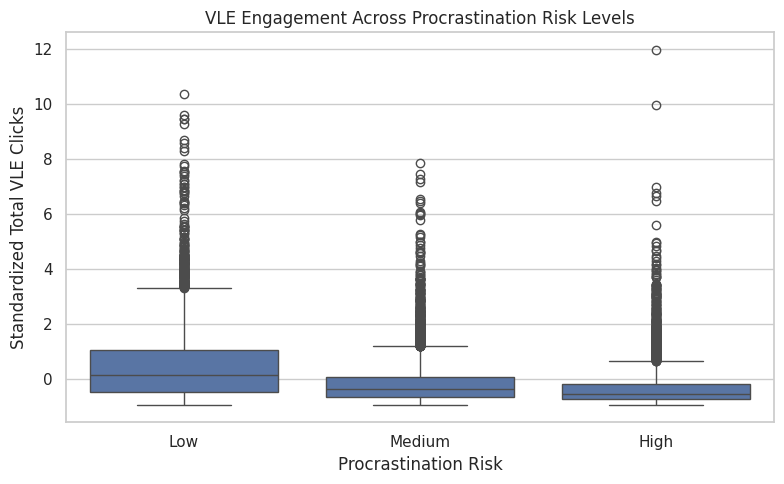

In [ ]:
#RISK VS VLE ENGAGEMENT
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='total_clicks',
    order=['Low', 'Medium', 'High']
)

plt.title('VLE Engagement Across Procrastination Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Standardized Total VLE Clicks')

plt.tight_layout()
plt.show()

In [ ]:
print("Median total clicks by risk:")
display(
    final_df.groupby('risk_label')['total_clicks']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median total clicks by risk:


,total_clicks
risk_label,
Low,0.167575
Medium,-0.357646
High,-0.539474


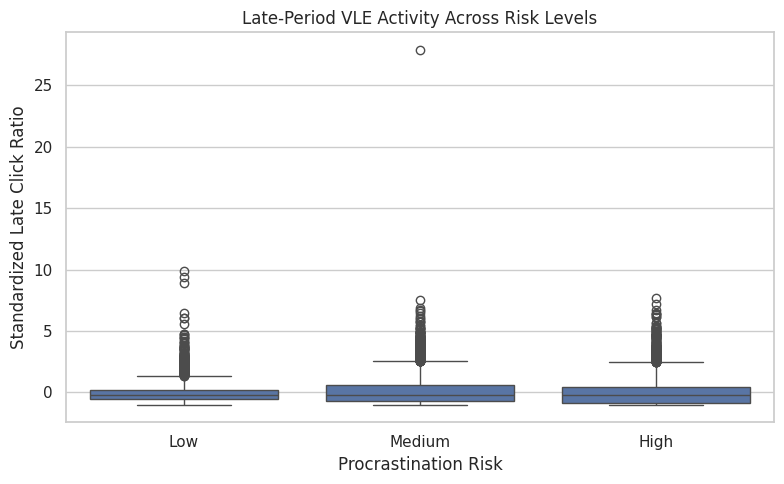

In [ ]:
#RISK VS LATE CLICK - RATIO
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='late_click_ratio',
    order=['Low', 'Medium', 'High']
)

plt.title('Late-Period VLE Activity Across Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Standardized Late Click Ratio')

plt.tight_layout()
plt.show()

In [ ]:
print("Median late click ratio by risk:")
display(
    final_df.groupby('risk_label')['late_click_ratio']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median late click ratio by risk:


,late_click_ratio
risk_label,
Low,-0.228389
Medium,-0.187978
High,-0.218837


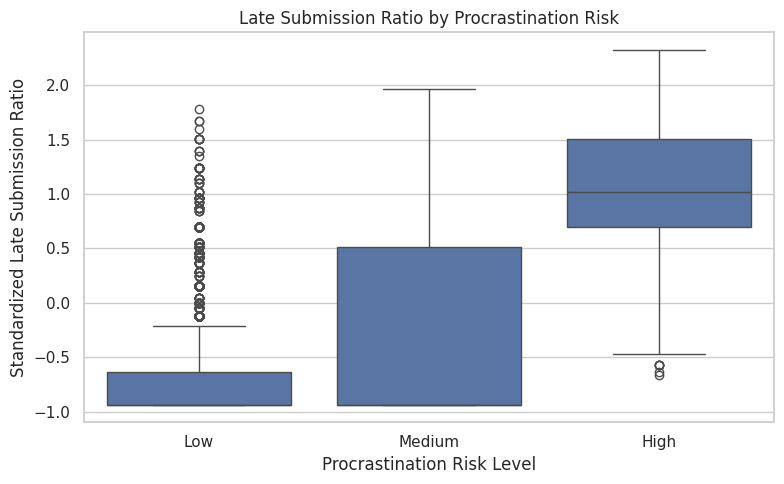

In [ ]:

# LATE SUBMISSION RATIO VS RISK


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='late_ratio',
    order=['Low', 'Medium', 'High']
)

plt.title('Late Submission Ratio by Procrastination Risk')
plt.xlabel('Procrastination Risk Level')
plt.ylabel('Standardized Late Submission Ratio')

plt.tight_layout()
plt.show()

In [ ]:
print("Median late submission ratio by risk:")
display(
    final_df.groupby('risk_label')['late_ratio']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median late submission ratio by risk:


,late_ratio
risk_label,
Low,-0.932383
Medium,-0.932383
High,1.019914


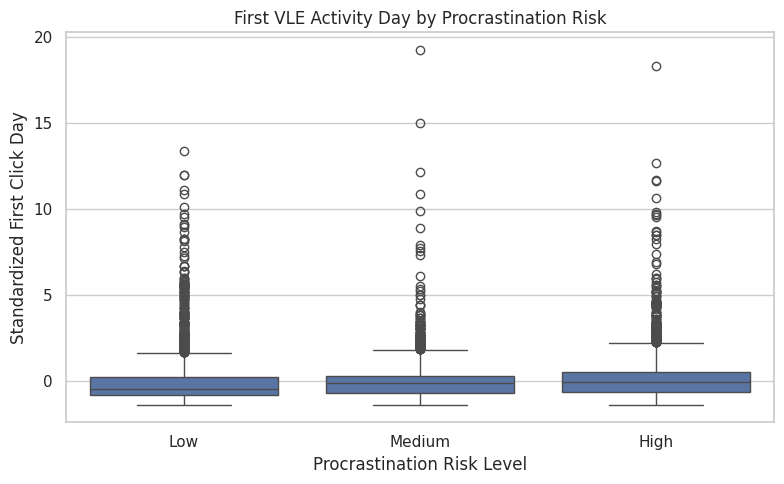

In [ ]:

# FIRST CLICK DAY VS RISK


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='first_click_day',
    order=['Low', 'Medium', 'High']
)

plt.title('First VLE Activity Day by Procrastination Risk')
plt.xlabel('Procrastination Risk Level')
plt.ylabel('Standardized First Click Day')

plt.tight_layout()
plt.show()

In [ ]:
print("Median first click day by risk:")
display(
    final_df.groupby('risk_label')['first_click_day']
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

Median first click day by risk:


,first_click_day
risk_label,
Low,-0.444530
Medium,-0.113407
High,-0.030627


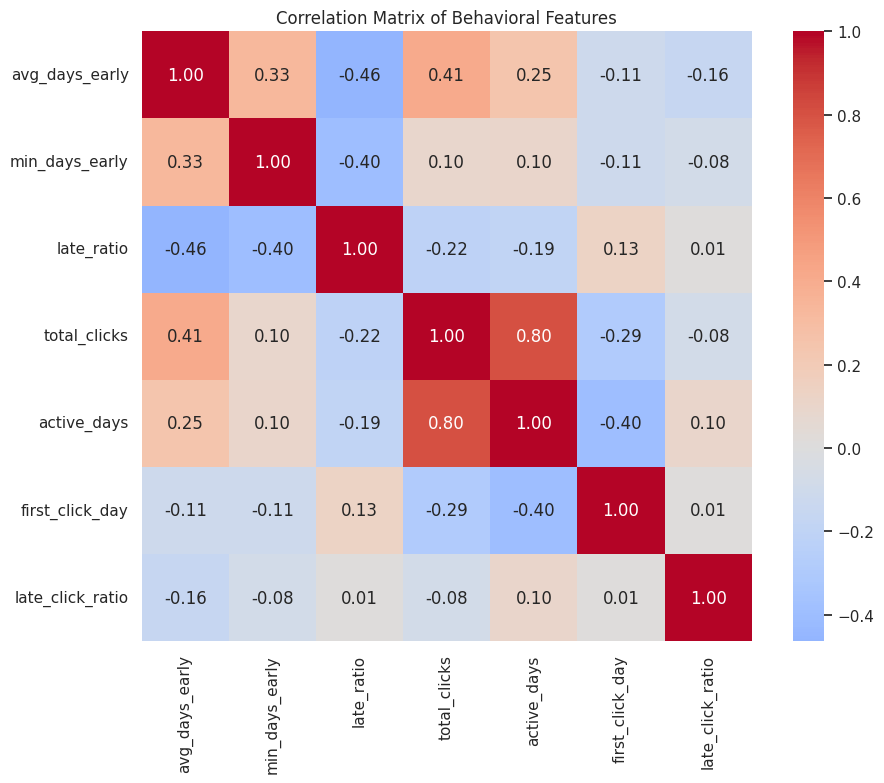

In [ ]:
#CORRELATION MATRIX
corr = final_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)

plt.title('Correlation Matrix of Behavioral Features')

plt.tight_layout()
plt.show()

In [ ]:
#STRONGEST CORRELATIONS AUTOMATICALLY
corr_pairs = (
    corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(key=abs, ascending=False)
)

print("Feature pairs ordered by correlation strength:")
display(corr_pairs)

Feature pairs ordered by correlation strength:


total_clicks     active_days         0.803779
avg_days_early   late_ratio         -0.463652
                 total_clicks        0.409862
min_days_early   late_ratio         -0.400708
active_days      first_click_day    -0.399267
avg_days_early   min_days_early      0.327941
total_clicks     first_click_day    -0.286941
avg_days_early   active_days         0.248262
late_ratio       total_clicks       -0.217575
                 active_days        -0.193003
avg_days_early   late_click_ratio   -0.155766
late_ratio       first_click_day     0.129344
avg_days_early   first_click_day    -0.113476
min_days_early   first_click_day    -0.110842
                 active_days         0.101688
active_days      late_click_ratio    0.097593
min_days_early   total_clicks        0.095454
total_clicks     late_click_ratio   -0.080382
min_days_early   late_click_ratio   -0.076544
first_click_day  late_click_ratio    0.013540
late_ratio       late_click_ratio    0.011171
dtype: float64

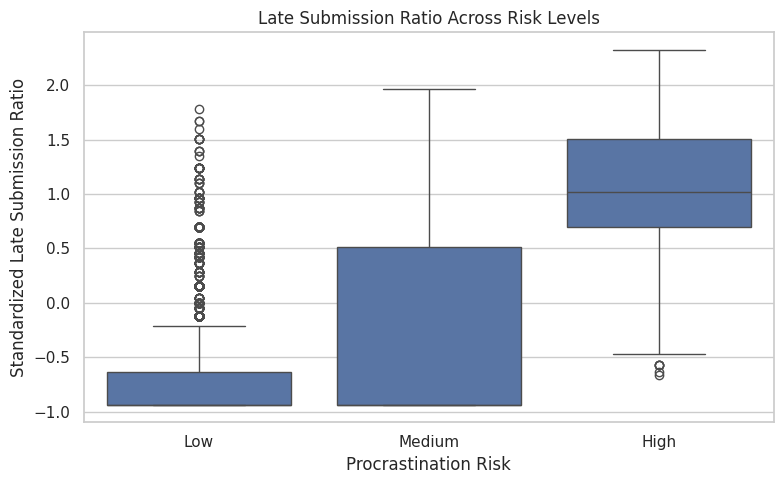

In [ ]:
#RISK VS LATE-RATIO
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='late_ratio',
    order=['Low', 'Medium', 'High']
)

plt.title('Late Submission Ratio Across Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Standardized Late Submission Ratio')

plt.tight_layout()
plt.show()


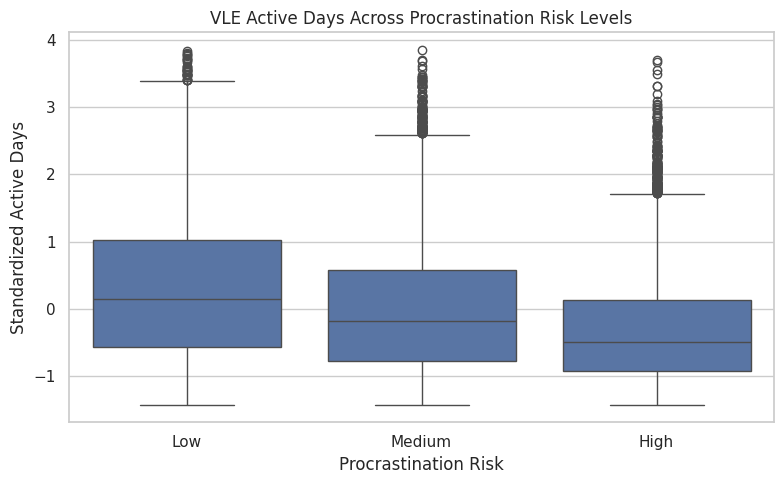

In [ ]:
#RISK VS ACTIVE_DAYS
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=final_df,
    x='risk_label',
    y='active_days',
    order=['Low', 'Medium', 'High']
)

plt.title('VLE Active Days Across Procrastination Risk Levels')
plt.xlabel('Procrastination Risk')
plt.ylabel('Standardized Active Days')

plt.tight_layout()
plt.show()

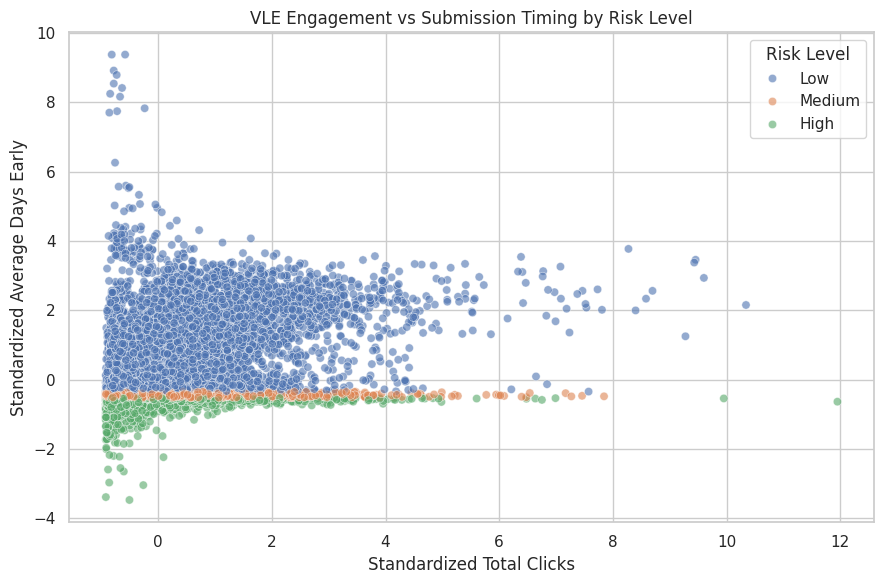

In [ ]:

#VLE ENGAGEMENT VS SUBMISSION TIMING


plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=final_df,
    x='total_clicks',
    y='avg_days_early',
    hue='risk_label',
    hue_order=['Low', 'Medium', 'High'],
    alpha=0.6
)

plt.title('VLE Engagement vs Submission Timing by Risk Level')
plt.xlabel('Standardized Total Clicks')
plt.ylabel('Standardized Average Days Early')
plt.legend(title='Risk Level')

plt.tight_layout()
plt.show()

In [ ]:

# RISK GROUP MEDIAN COMPARISON


risk_medians = (
    final_df
    .groupby('risk_label')[numeric_cols]
    .median()
    .reindex(['Low', 'Medium', 'High'])
)

display(risk_medians)

,avg_days_early,min_days_early,late_ratio,total_clicks,active_days,first_click_day,late_click_ratio
risk_label,,,,,,,
Low,1.042377,0.429484,-0.932383,0.167575,0.149310,-0.444530,-0.228389
Medium,-0.467286,0.429484,-0.932383,-0.357646,-0.183874,-0.113407,-0.187978
High,-0.584415,-0.164427,1.019914,-0.539474,-0.498547,-0.030627,-0.218837


In [ ]:

# COMPARE MEDIANS


for col in numeric_cols:

    medians = (
        final_df
        .groupby('risk_label')[col]
        .median()
        .reindex(['Low', 'Medium', 'High'])
    )

    print(f"\n{col}")
    print(medians)
    print("Lowest median risk group:", medians.idxmin())
    print("Highest median risk group:", medians.idxmax())


avg_days_early
risk_label
Low       1.042377
Medium   -0.467286
High     -0.584415
Name: avg_days_early, dtype: float64
Lowest median risk group: High
Highest median risk group: Low

min_days_early
risk_label
Low       0.429484
Medium    0.429484
High     -0.164427
Name: min_days_early, dtype: float64
Lowest median risk group: High
Highest median risk group: Low

late_ratio
risk_label
Low      -0.932383
Medium   -0.932383
High      1.019914
Name: late_ratio, dtype: float64
Lowest median risk group: Low
Highest median risk group: High

total_clicks
risk_label
Low       0.167575
Medium   -0.357646
High     -0.539474
Name: total_clicks, dtype: float64
Lowest median risk group: High
Highest median risk group: Low

active_days
risk_label
Low       0.149310
Medium   -0.183874
High     -0.498547
Name: active_days, dtype: float64
Lowest median risk group: High
Highest median risk group: Low

first_click_day
risk_label
Low      -0.444530
Medium   -0.113407
High     -0.030627
Name: first_click_

#Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# dropping identifier columns + leakage columns used to build risk_label
drop_cols = ['code_module', 'code_presentation', 'id_student', 'risk_label',
             'date_unregistration', 'avg_days_early', 'late_click_ratio', 'late_clicks']

X = final_df.drop(columns=drop_cols)
y = final_df['risk_label']

# encoding the target labels (Low/Medium/High) into numbers (0/1/2)
# needed for deep learning models and also fine for classical models
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)  # shows which number maps to which label
print("X shape:", X.shape)
print("y shape:", y_encoded.shape)


# SPLIT FOR CLASSICAL / TRADITIONAL MODELS
# (Logistic Regression, Decision Tree, Random Forest)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("\n--- Classical models split ---")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# X_train, X_test stay as pandas DataFrames here
# sklearn models (LogisticRegression, DecisionTreeClassifier, RandomForestClassifier)


# SPLIT FOR MLP / FT-TRANSFORMER
# (deep learning models that need train/validation/test)
# first split off the test set (same as classical, keeps comparison fair)
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# then split training data further into train/validation
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_dl, y_train_dl,
    test_size=0.2,
    stratify=y_train_dl,
    random_state=42
)

print("\n--- MLP / FT-Transformer split ---")
print("X_train_dl:", X_train_dl.shape)
print("X_val_dl:", X_val_dl.shape)
print("X_test_dl:", X_test_dl.shape)

# converting to numpy arrays with float type, since neural networks expect numeric arrays not DataFrames
X_train_dl = X_train_dl.values.astype('float32')
X_val_dl = X_val_dl.values.astype('float32')
X_test_dl = X_test_dl.values.astype('float32')


# ================================
# SPLIT FOR TABNET
# (needs numpy arrays specifically, and its own eval_set format)
# ================================
X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# TabNet also benefits from its own validation set for early stopping
X_train_tab, X_valid_tab, y_train_tab, y_valid_tab = train_test_split(
    X_train_tab, y_train_tab,
    test_size=0.2,
    stratify=y_train_tab,
    random_state=42
)


Classes: ['High' 'Low' 'Medium']
X shape: (20996, 46)
y shape: (20996,)

--- Classical models split ---
X_train: (16796, 46)
X_test: (4200, 46)
y_train: (16796,)
y_test: (4200,)

--- MLP / FT-Transformer split ---
X_train_dl: (13436, 46)
X_val_dl: (3360, 46)
X_test_dl: (4200, 46)


#Model Implementation

#Ashfia's part

Random Forest Results
Accuracy: 0.8376190476190476
F1 Score: 0.8372461214537302
AUC: 0.9476607928384765
              precision    recall  f1-score   support

        High       0.83      0.92      0.87      1399
         Low       0.91      0.83      0.87      1432
      Medium       0.78      0.76      0.77      1369

    accuracy                           0.84      4200
   macro avg       0.84      0.84      0.84      4200
weighted avg       0.84      0.84      0.84      4200



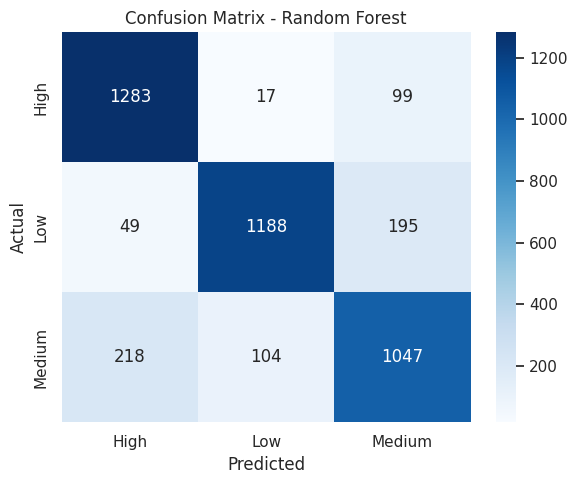

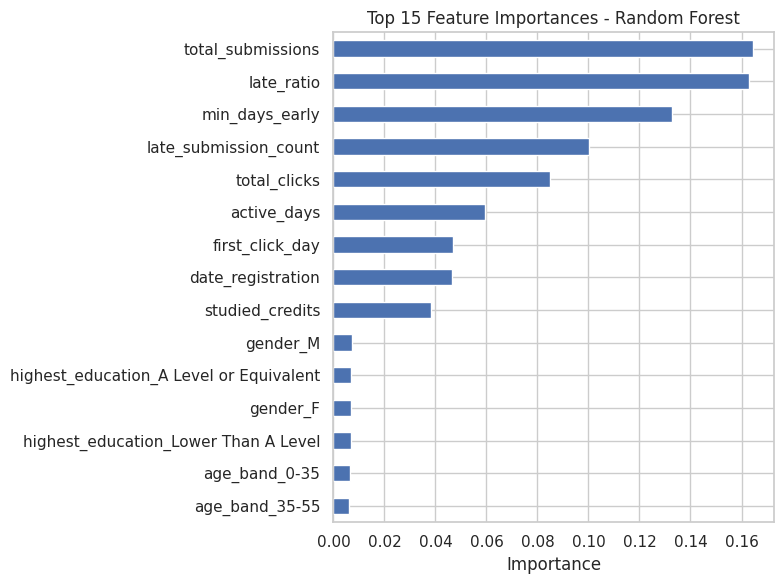

In [ ]:
# ================================
# RANDOM FOREST
# ================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# building and training the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# fit kept throwing a DataFrame error, looks like the GPU runtime patched sklearn to cuML
# converting to numpy with .values fixes it
rf_model.fit(X_train.values, y_train)

# predicting on test set
rf_pred = rf_model.predict(X_test.values)
rf_proba = rf_model.predict_proba(X_test.values)

# metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_auc = roc_auc_score(y_test, rf_proba, multi_class='ovr')

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("F1 Score:", rf_f1)
print("AUC:", rf_auc)
print(classification_report(y_test, rf_pred, target_names=le.classes_))

# want to see which classes are getting mixed up with which
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

# feature importance, want to compare this against tabnet's later
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# saving this so I don't lose it when I run the other models below
results = {}
results['Random Forest'] = {'Accuracy': rf_accuracy, 'F1': rf_f1, 'AUC': rf_auc}




/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.98878 | val_0_accuracy: 0.64107 |  0:00:03s
epoch 1  | loss: 0.72773 | val_0_accuracy: 0.63363 |  0:00:06s
epoch 2  | loss: 0.63672 | val_0_accuracy: 0.72113 |  0:00:07s
epoch 3  | loss: 0.56366 | val_0_accuracy: 0.75714 |  0:00:09s
epoch 4  | loss: 0.55011 | val_0_accuracy: 0.77768 |  0:00:10s
epoch 5  | loss: 0.53701 | val_0_accuracy: 0.78839 |  0:00:12s
epoch 6  | loss: 0.51819 | val_0_accuracy: 0.78601 |  0:00:13s
epoch 7  | loss: 0.50357 | val_0_accuracy: 0.79821 |  0:00:15s
epoch 8  | loss: 0.49112 | val_0_accuracy: 0.80298 |  0:00:16s
epoch 9  | loss: 0.47688 | val_0_accuracy: 0.80714 |  0:00:19s
epoch 10 | loss: 0.47285 | val_0_accuracy: 0.81875 |  0:00:22s
epoch 11 | loss: 0.46439 | val_0_accuracy: 0.81518 |  0:00:23s
epoch 12 | loss: 0.46524 | val_0_accuracy: 0.80744 |  0:00:24s
epoch 13 | loss: 0.46514 | val_0_accuracy: 0.7997  |  0:00:26s
epoch 14 | loss: 0.46603 | val_0_accuracy: 0.81101 |  0:00:27s
epoch 15 | loss: 0.44825 | val_0_accuracy: 0.80804 |  0

/usr/local/lib/python3.13/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Results
Accuracy: 0.83
F1 Score: 0.8298252540724248
AUC: 0.9487910871155232
              precision    recall  f1-score   support

        High       0.83      0.89      0.86      1399
         Low       0.90      0.84      0.87      1432
      Medium       0.77      0.75      0.76      1369

    accuracy                           0.83      4200
   macro avg       0.83      0.83      0.83      4200
weighted avg       0.83      0.83      0.83      4200



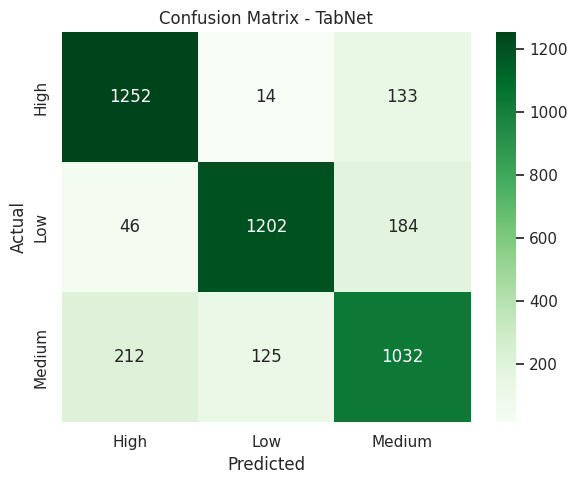

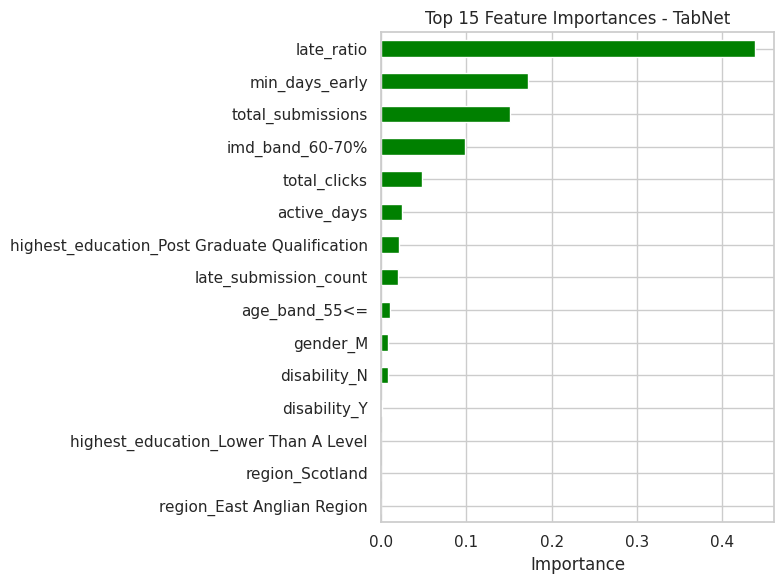

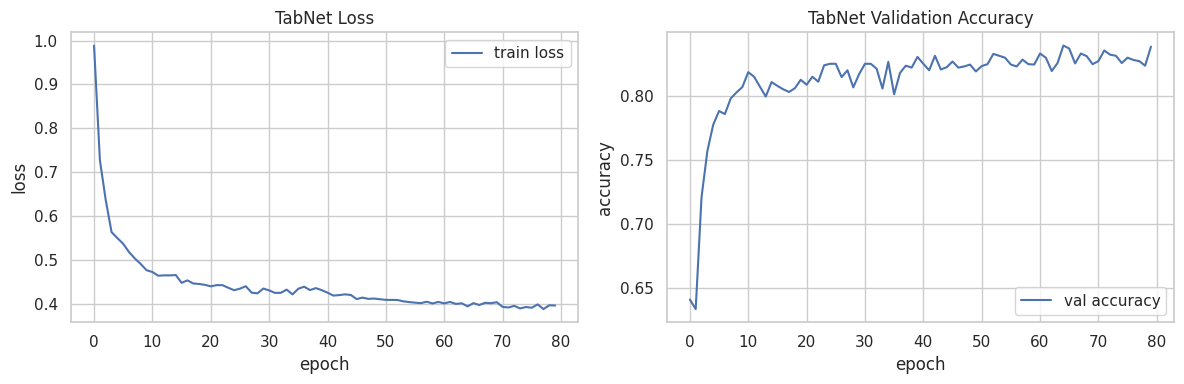

In [ ]:
# ================================
# TABNET
# ================================
# only need to run this pip install once per session
!pip install pytorch-tabnet --quiet

from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# building the model
tabnet_model = TabNetClassifier(
    n_d=8, n_a=8,          # width of decision/attention layers
    n_steps=3,             # number of decision steps
    gamma=1.5,
    seed=42,
    verbose=1,
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)

# feeding in the validation set so it can stop early instead of overfitting
# tabnet's dataloader errors on mixed bool/float columns, casting everything to float32 first
X_train_tab = X_train_tab.astype('float32')
X_valid_tab = X_valid_tab.astype('float32')
X_test_tab = X_test_tab.astype('float32')

tabnet_model.fit(
    X_train=X_train_tab.values, y_train=y_train_tab,
    eval_set=[(X_valid_tab.values, y_valid_tab)],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=15,
    batch_size=256,
    virtual_batch_size=64
)

# predicting on test set
tabnet_pred = tabnet_model.predict(X_test_tab.values)
tabnet_proba = tabnet_model.predict_proba(X_test_tab.values)

# metrics
tabnet_accuracy = accuracy_score(y_test_tab, tabnet_pred)
tabnet_f1 = f1_score(y_test_tab, tabnet_pred, average='weighted')
tabnet_auc = roc_auc_score(y_test_tab, tabnet_proba, multi_class='ovr')

print("\nTabNet Results")
print("Accuracy:", tabnet_accuracy)
print("F1 Score:", tabnet_f1)
print("AUC:", tabnet_auc)
print(classification_report(y_test_tab, tabnet_pred, target_names=le.classes_))

# same confusion matrix check as random forest, for comparison later
cm_tabnet = confusion_matrix(y_test_tab, tabnet_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tabnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TabNet')
plt.tight_layout()
plt.show()

# tabnet has its own feature importance built in, different mechanism than RF's
tabnet_importances = pd.Series(tabnet_model.feature_importances_, index=X_train_tab.columns)
tabnet_importances = tabnet_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
tabnet_importances.plot(kind='barh', color='green')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - TabNet')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# plotting tabnet's training history (loss and accuracy across epochs)
# tabnet automatically stores this in .history, no need to track it manually
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(tabnet_model.history['loss'], label='train loss')
plt.title('TabNet Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(tabnet_model.history['val_0_accuracy'], label='val accuracy')
plt.title('TabNet Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# adding to the same results dict as random forest
results['TabNet'] = {'Accuracy': tabnet_accuracy, 'F1': tabnet_f1, 'AUC': tabnet_auc}

#Afra's part

Decision Tree Results
Accuracy: 0.8178571428571428
F1 Score: 0.8183503829743484
AUC: 0.9343099422625757
              precision    recall  f1-score   support

        High       0.84      0.87      0.86      1399
         Low       0.88      0.83      0.85      1432
      Medium       0.73      0.76      0.74      1369

    accuracy                           0.82      4200
   macro avg       0.82      0.82      0.82      4200
weighted avg       0.82      0.82      0.82      4200



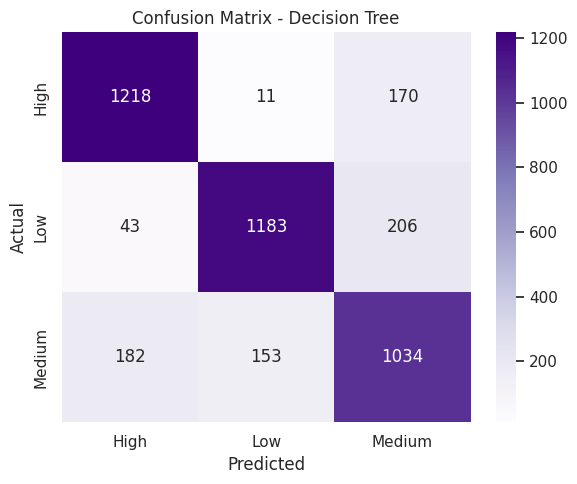

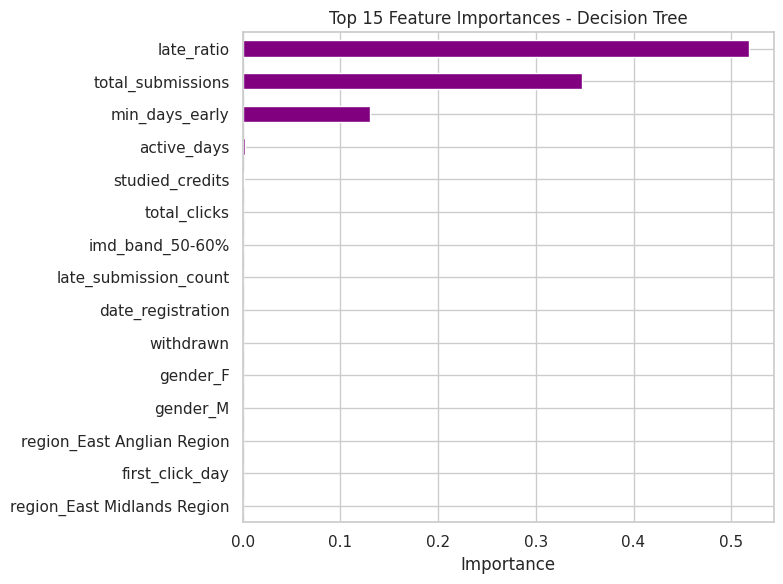

In [ ]:
# ================================
# DECISION TREE
# ================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train.values, y_train)

dt_pred = dt_model.predict(X_test.values)
dt_proba = dt_model.predict_proba(X_test.values)

dt_accuracy = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
dt_auc = roc_auc_score(y_test, dt_proba, multi_class='ovr')

print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("F1 Score:", dt_f1)
print("AUC:", dt_auc)
print(classification_report(y_test, dt_pred, target_names=le.classes_))

cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

# feature importance, same approach as random forest, easy to compare later
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
dt_importances = dt_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
dt_importances.plot(kind='barh', color='purple')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

results['Decision Tree'] = {'Accuracy': dt_accuracy, 'F1': dt_f1, 'AUC': dt_auc}

Epoch 1 | Train Loss: 0.9298 Acc: 0.5318 | Val Loss: 0.6021 Acc: 0.7515
Epoch 2 | Train Loss: 0.6179 Acc: 0.7356 | Val Loss: 0.5480 Acc: 0.7562
Epoch 3 | Train Loss: 0.5686 Acc: 0.7584 | Val Loss: 0.5058 Acc: 0.7830
Epoch 4 | Train Loss: 0.5592 Acc: 0.7612 | Val Loss: 0.4888 Acc: 0.7949
Epoch 5 | Train Loss: 0.5337 Acc: 0.7750 | Val Loss: 0.4866 Acc: 0.7878
Epoch 6 | Train Loss: 0.5219 Acc: 0.7810 | Val Loss: 0.4938 Acc: 0.7801
Epoch 7 | Train Loss: 0.5088 Acc: 0.7870 | Val Loss: 0.4882 Acc: 0.7884
Epoch 8 | Train Loss: 0.5043 Acc: 0.7885 | Val Loss: 0.4915 Acc: 0.7833
Epoch 9 | Train Loss: 0.5000 Acc: 0.7880 | Val Loss: 0.4626 Acc: 0.7976
Epoch 10 | Train Loss: 0.4819 Acc: 0.8027 | Val Loss: 0.4515 Acc: 0.8089
Epoch 11 | Train Loss: 0.4775 Acc: 0.8044 | Val Loss: 0.4363 Acc: 0.8149
Epoch 12 | Train Loss: 0.4755 Acc: 0.8037 | Val Loss: 0.4537 Acc: 0.8042
Epoch 13 | Train Loss: 0.4714 Acc: 0.8052 | Val Loss: 0.4456 Acc: 0.8107
Epoch 14 | Train Loss: 0.4648 Acc: 0.8104 | Val Loss: 0.4405

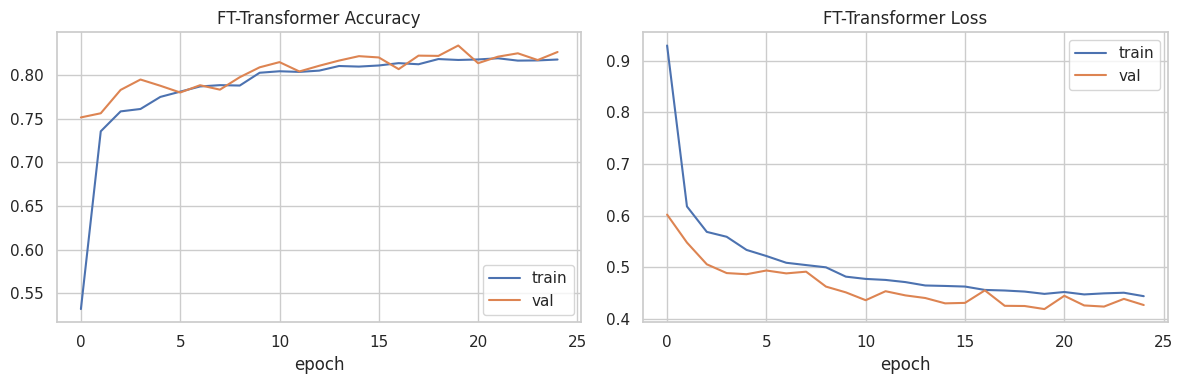


FT-Transformer Results
Accuracy: 0.8254761904761905
F1 Score: 0.8277028653533287
AUC: 0.9428677435350604
              precision    recall  f1-score   support

        High       0.86      0.85      0.85      1399
         Low       0.93      0.80      0.86      1432
      Medium       0.72      0.83      0.77      1369

    accuracy                           0.83      4200
   macro avg       0.83      0.83      0.83      4200
weighted avg       0.84      0.83      0.83      4200



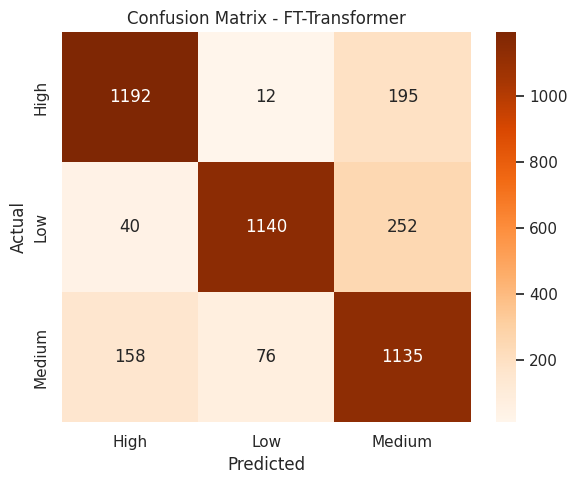

In [ ]:
# ================================
# FT-TRANSFORMER
# ================================
!pip install -q rtdl-revisiting-models

from rtdl_revisiting_models import FTTransformer
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# turning the numpy arrays into tensors, then wrapping into loaders that feed data in batches
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_dl, dtype=torch.float32),
                                         torch.tensor(y_train_dl, dtype=torch.long)),
                           batch_size=128, shuffle=True)

val_loader = DataLoader(TensorDataset(torch.tensor(X_val_dl, dtype=torch.float32),
                                       torch.tensor(y_val_dl, dtype=torch.long)),
                         batch_size=128, shuffle=False)

test_loader = DataLoader(TensorDataset(torch.tensor(X_test_dl, dtype=torch.float32),
                                        torch.tensor(y_test_dl, dtype=torch.long)),
                          batch_size=128, shuffle=False)

# building a small FT-Transformer, kept small since we're on CPU/limited GPU
ft_model = FTTransformer(
    n_cont_features=X_train_dl.shape[1],
    cat_cardinalities=[],
    d_out=len(le.classes_),
    d_block=32,
    n_blocks=1,
    attention_n_heads=2,
    ffn_d_hidden_multiplier=2.0,
    residual_dropout=0.1,
    attention_dropout=0.1,
    ffn_dropout=0.1
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=0.001, weight_decay=0.0001)

# one function that can either train or just evaluate, depending on the flag
def run_epoch(loader, training):
    ft_model.train() if training else ft_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            output = ft_model(x_cont=X_batch, x_cat=None)
            loss = criterion(output, y_batch)
            if training:
                loss.backward()
                optimizer.step()

        preds = torch.argmax(output, dim=1)
        total_loss += loss.item() * X_batch.size(0)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

        if not training:
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            all_probs.extend(torch.softmax(output, dim=1).cpu().detach().numpy())

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_labels), np.array(all_preds), np.array(all_probs)


# training loop with early stopping if validation loss stops improving
best_val_loss = float('inf')
patience, wait = 5, 0
best_state = None

# keeping track of loss/accuracy at each epoch so we can plot it afterward
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(30):
    train_loss, train_acc, _, _, _ = run_epoch(train_loader, training=True)
    val_loss, val_acc, _, _, _ = run_epoch(val_loader, training=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
          f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in ft_model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print("Stopping early.")
            break

ft_model.load_state_dict(best_state)

# plotting the loss and accuracy curves collected during training
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='train')
plt.plot(val_accs, label='val')
plt.title('FT-Transformer Accuracy')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('FT-Transformer Loss')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
plt.show()

# final evaluation on the test set
_, ft_accuracy, y_true_ft, y_pred_ft, y_proba_ft = run_epoch(test_loader, training=False)

ft_f1 = f1_score(y_true_ft, y_pred_ft, average='weighted')
ft_auc = roc_auc_score(y_true_ft, y_proba_ft, multi_class='ovr')

print("\nFT-Transformer Results")
print("Accuracy:", ft_accuracy)
print("F1 Score:", ft_f1)
print("AUC:", ft_auc)
print(classification_report(y_true_ft, y_pred_ft, target_names=le.classes_))

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - FT-Transformer')
plt.tight_layout()
plt.show()

results['FT-Transformer'] = {'Accuracy': ft_accuracy, 'F1': ft_f1, 'AUC': ft_auc}

# Dola's part

Logistic Regression Accuracy: 0.79

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.87      0.85      1399
         Low       0.87      0.76      0.81      1432
      Medium       0.69      0.73      0.71      1369

    accuracy                           0.79      4200
   macro avg       0.79      0.79      0.79      4200
weighted avg       0.79      0.79      0.79      4200



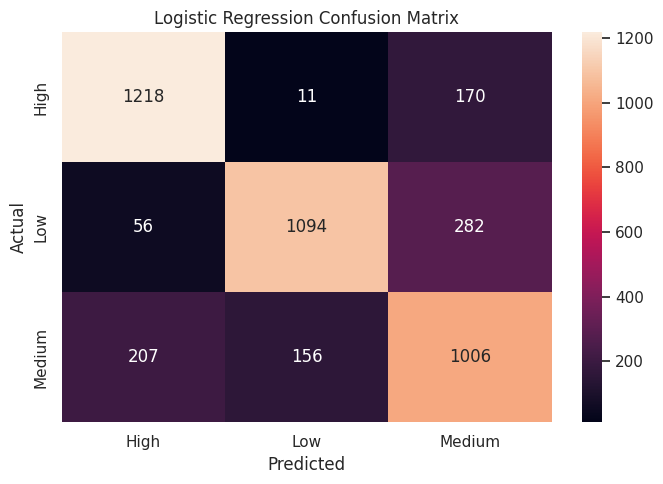

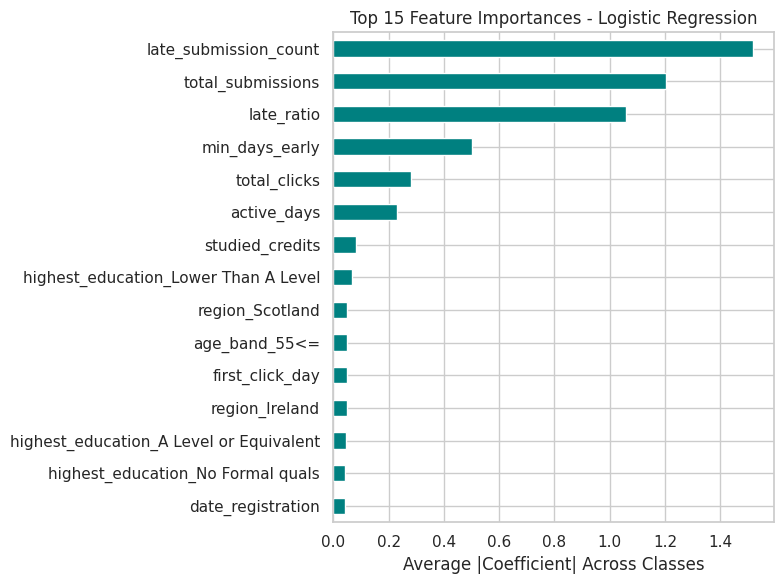

In [ ]:
# logistic regression (classical model)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# data already split & cleaned > X_train, X_test, y_train, y_test
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)

# training
logreg = LogisticRegression(max_iter=2000, random_state=42)
logreg.fit(X_train_lr, y_train)

# predicting
y_pred = logreg.predict(X_test_lr)

# evaluation
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# feature importance for logistic regression comes from its coefficients
# one row of coefficients per class cz a multi-class problem
coef_df = pd.DataFrame(logreg.coef_, columns=X_train.columns, index=le.classes_)

#classes to rank overall importance
avg_importance = coef_df.abs().mean(axis=0).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
avg_importance.plot(kind='barh', color='teal')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Logistic Regression')
plt.xlabel('Average |Coefficient| Across Classes')
plt.tight_layout()
plt.show()
results['Logistic Regression'] = {'Accuracy': accuracy_score(y_test, y_pred), 'F1': f1_score(y_test, y_pred, average='weighted'), 'AUC': roc_auc_score(y_test, logreg.predict_proba(X_test_lr), multi_class='ovr')}

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,187 (20.26 KB)

 Trainable params: 5,187 (20.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.3410 - loss: 3.2841 - val_accuracy: 0.3408 - val_loss: 1.0976
Epoch 2/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3480 - loss: 1.1501 - val_accuracy: 0.3458 - val_loss: 1.0990
Epoch 3/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3549 - loss: 1.1105 - val_accuracy: 0.3577 - val_loss: 1.0984
Epoch 4/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3632 - loss: 1.1071 - val_accuracy: 0.3732 - val_loss: 1.0955
Epoch 5/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3689 - loss: 1.1024 - val_accuracy: 0.3917 - val_loss: 1.0917
Epoch 6/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3989 - loss: 1.0889 - val_accuracy: 0.4848 - val_loss: 1.0678
Epoch 7/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4449 - loss: 1.0496 - val_accuracy: 0.5515 - val_loss: 0.9999
Epoch 8/100
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5157 - loss: 0.9818 - val_a

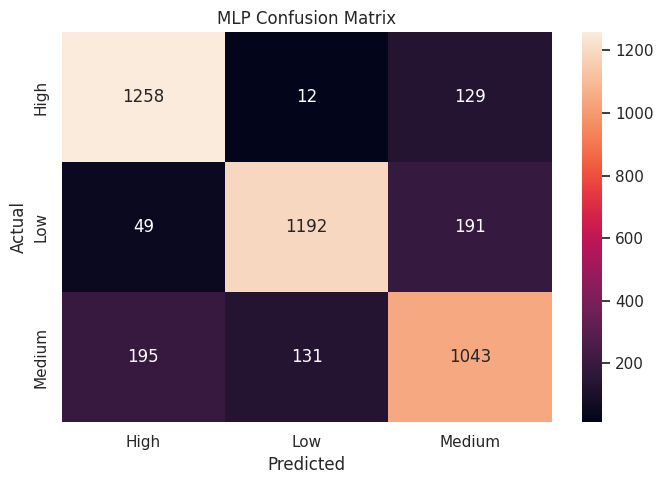

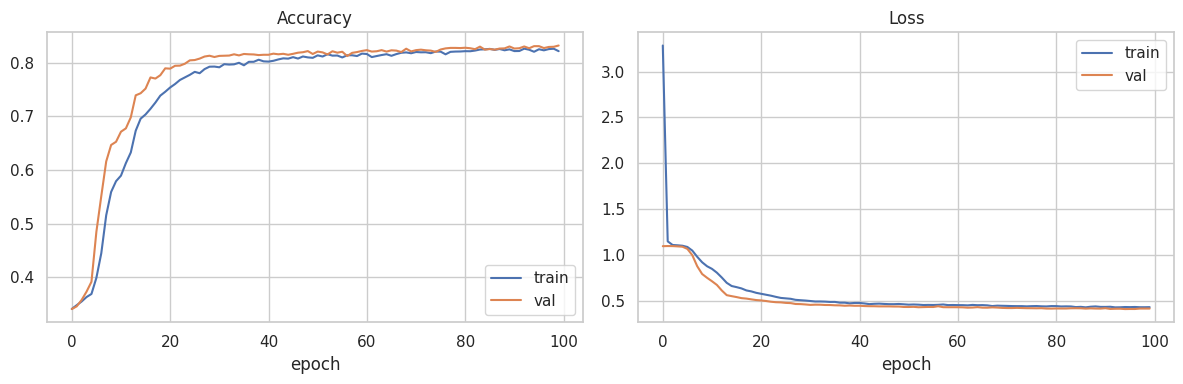

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# mlp (deep learning model)
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

tf.random.set_seed(42)
np.random.seed(42)

# data already split & cleaned
# X_train_dl, X_val_dl, X_test_dl (float32) and y_train_dl, y_val_dl, y_test_dl
num_classes = len(le.classes_)

# building mlp: input -> 64 -> 32 -> softmax(3)
model = Sequential([
    Input(shape=(X_train_dl.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# training with validation set + early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_dl, y_train_dl,
                    validation_data=(X_val_dl, y_val_dl),
                    epochs=100, batch_size=64,
                    callbacks=[early_stop], verbose=1)

# predicting on the test set
y_pred_mlp = np.argmax(model.predict(X_test_dl), axis=1)

# evaluation
print("MLP Accuracy:", round(accuracy_score(y_test_dl, y_pred_mlp), 4))
print("\nClassification Report:")
print(classification_report(y_test_dl, y_pred_mlp, target_names=le.classes_))

# confusion matrix
cm = confusion_matrix(y_test_dl, y_pred_mlp)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('MLP Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy'); plt.xlabel('epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout()
plt.show()
results['MLP'] = {'Accuracy': accuracy_score(y_test_dl, y_pred_mlp), 'F1': f1_score(y_test_dl, y_pred_mlp, average='weighted'), 'AUC': roc_auc_score(y_test_dl, model.predict(X_test_dl), multi_class='ovr')}

#Comparison

In [ ]:
print(results)

{'Random Forest': {'Accuracy': 0.8376190476190476, 'F1': 0.8372461214537302, 'AUC': np.float64(0.9476607928384765)}, 'TabNet': {'Accuracy': 0.83, 'F1': 0.8298252540724248, 'AUC': np.float64(0.9487910871155232)}, 'Decision Tree': {'Accuracy': 0.8178571428571428, 'F1': 0.8183503829743484, 'AUC': np.float64(0.9343099422625757)}, 'FT-Transformer': {'Accuracy': 0.8254761904761905, 'F1': 0.8277028653533287, 'AUC': np.float64(0.9428677435350604)}, 'Logistic Regression': {'Accuracy': 0.79, 'F1': 0.7907420403958122, 'AUC': np.float64(0.9240575213097316)}, 'MLP': {'Accuracy': 0.8316666666666667, 'F1': 0.8315266939099075, 'AUC': np.float64(0.9465603947141062)}}


In [ ]:
comparison_df = pd.DataFrame(results).T  # .T flips it so models are rows, metrics are columns
comparison_df = comparison_df.round(4)
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print(comparison_df)

                     Accuracy      F1     AUC
Random Forest          0.8376  0.8372  0.9477
MLP                    0.8317  0.8315  0.9466
TabNet                 0.8300  0.8298  0.9488
FT-Transformer         0.8255  0.8277  0.9429
Decision Tree          0.8179  0.8184  0.9343
Logistic Regression    0.7900  0.7907  0.9241


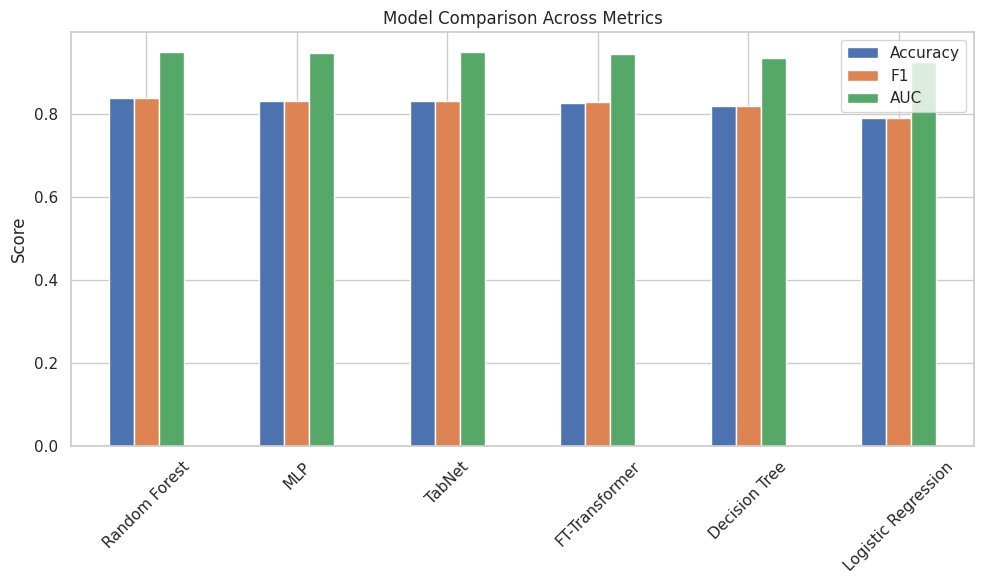

In [ ]:
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Comparison Across Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()